
# Pronóstico climático mensual 2025–2027

Este notebook toma como base `clima_mes_2005-2025.csv` y genera:

- entrenamiento de modelos por **municipio-variable**
- comparación entre modelos
- selección automática del mejor modelo
- pronóstico mensual hasta 2027
- archivo final `clima_mes_2005-2027.csv`

La lógica del notebook es pronosticar variables climáticas mensuales base y no las features derivadas del índice.


## 1. Librerías

In [3]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

## 2. Rutas, parámetros y carga de datos

In [4]:

PROJECT_ROOT = Path().resolve().parents[1]
path = PROJECT_ROOT / "data" / "processed"

archivo_entrada = path / "clima_mes_2005-2025.csv"

df = pd.read_csv(archivo_entrada)

df.head()


,municipio,date,anio,mes,precip_mm,precip_mean_mm,precip_max_mm,ndvi_mean,ndvi_min,ndvi_max,...,flag_precip_baja_p10,flag_precip_alta_p90,flag_deficit_alto_p90,flag_exceso_alto_p90,flag_temp_media_alta_p90,flag_temp_media_baja_p10,flag_temp_max_alta_p90,flag_temp_min_baja_p10,flag_ndvi_bajo_p10,flag_ndvi_alto_p90
0,Aguadas,2005-01-31,2005,1,114.152754,3.682347,30.293657,0.679196,0.0297,0.9985,...,0,0,0,0,0,0,0,0,1,0
1,Aguadas,2005-02-28,2005,2,92.367963,3.298856,34.730915,0.694763,0.0376,0.9993,...,0,0,0,0,0,0,0,0,0,0
2,Aguadas,2005-03-31,2005,3,212.648689,6.859635,30.772394,0.735368,0.0487,0.9991,...,0,0,0,0,0,0,0,0,0,1
3,Aguadas,2005-04-30,2005,4,222.890335,7.429678,19.728767,0.683401,0.0158,0.9988,...,0,0,1,0,0,0,0,0,0,0
4,Aguadas,2005-05-31,2005,5,365.459124,11.789004,38.967903,0.756183,0.0261,0.9982,...,0,0,1,0,0,0,0,1,0,0


In [5]:

# Parámetros principales

COL_MUNICIPIO = "municipio"
COL_ANIO = "anio"
COL_MES = "mes"

# Si se deja en None, el pronóstico empieza en el mes siguiente al último dato observado.
# Si quieres forzar pronóstico desde enero de 2025, usa: "2025-01-01"
FECHA_INICIO_PRONOSTICO = None

FECHA_FIN_PRONOSTICO = "2027-12-01"

TEST_SIZE = 0.10
RANDOM_STATE = 42

# Variables climáticas base esperadas.
# El notebook usará únicamente las que existan en el archivo.
variables_base_esperadas = [
    "precip_mm",
    "precip_mean_mm",
    "precip_max_mm",
    "temp_mean",
    "temp_min",
    "temp_max",
    "et_real_mm",
    "et_potencial_mm",
    "ndvi_mean",
    "ndvi_min",
    "ndvi_max"
]


## 3. Validación y preparación temporal

In [6]:

# Validaciones mínimas
cols_base = [COL_MUNICIPIO, COL_ANIO, COL_MES]
faltantes = [c for c in cols_base if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas base en el archivo mensual: {faltantes}")

# Variables climáticas disponibles
variables_clima = [v for v in variables_base_esperadas if v in df.columns]

if len(variables_clima) == 0:
    raise ValueError("No se encontró ninguna variable climática base esperada.")

print("Variables climáticas a pronosticar:")
print(variables_clima)

# Crear fecha mensual
df[COL_ANIO] = df[COL_ANIO].astype(int)
df[COL_MES] = df[COL_MES].astype(int)

df["date"] = pd.to_datetime(
    df[COL_ANIO].astype(str) + "-" + df[COL_MES].astype(str).str.zfill(2) + "-01"
)

# Ordenar
df = df.sort_values([COL_MUNICIPIO, "date"]).reset_index(drop=True)

print("Rango observado:")
print(df["date"].min(), "→", df["date"].max())
print("Municipios:", df[COL_MUNICIPIO].nunique())
print("Filas:", len(df))


Variables climáticas a pronosticar:
['precip_mm', 'precip_mean_mm', 'precip_max_mm', 'temp_mean', 'temp_min', 'temp_max', 'et_real_mm', 'et_potencial_mm', 'ndvi_mean', 'ndvi_min', 'ndvi_max']
Rango observado:
2005-01-01 00:00:00 → 2025-12-01 00:00:00
Municipios: 27
Filas: 6804


In [7]:

# Convertir variables climáticas a numéricas
for v in variables_clima:
    df[v] = pd.to_numeric(df[v], errors="coerce")

# Revisar faltantes
faltantes_vars = df[variables_clima].isna().mean().sort_values(ascending=False)
faltantes_vars


et_real_mm         0.047619
et_potencial_mm    0.047619
precip_mm          0.000000
precip_mean_mm     0.000000
precip_max_mm      0.000000
temp_mean          0.000000
temp_min           0.000000
temp_max           0.000000
ndvi_mean          0.000000
ndvi_min           0.000000
ndvi_max           0.000000
dtype: float64

## 4. Funciones auxiliares de pronóstico

In [8]:

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def split_train_test(serie, test_size=0.10):
    n = len(serie)
    n_test = max(1, int(np.ceil(n * test_size)))
    train = serie.iloc[:-n_test]
    test = serie.iloc[-n_test:]
    return train, test


def forecast_seasonal_naive(train, fechas_objetivo):
    """
    Pronóstico por climatología mensual:
    para cada mes futuro usa el promedio histórico de ese mes.
    """
    train_df = train.to_frame("y")
    train_df["mes"] = train_df.index.month

    clim = train_df.groupby("mes")["y"].mean()
    fallback = train.mean()

    preds = []
    for fecha in fechas_objetivo:
        preds.append(clim.get(fecha.month, fallback))

    return pd.Series(preds, index=fechas_objetivo)


def forecast_sarima(train, fechas_objetivo):
    """
    SARIMA con una grilla pequeña para evitar tiempos excesivos.
    """
    if not STATSMODELS_OK:
        raise RuntimeError("statsmodels no está disponible.")

    best_aic = np.inf
    best_model = None

    orders = [
        (1, 0, 0),
        (0, 1, 1),
        (1, 1, 0),
        (1, 1, 1)
    ]

    seasonal_orders = [
        (1, 0, 0, 12),
        (0, 1, 1, 12),
        (1, 1, 0, 12)
    ]

    for order in orders:
        for seasonal_order in seasonal_orders:
            try:
                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fit = model.fit(disp=False)

                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_model = fit
            except Exception:
                continue

    if best_model is None:
        raise RuntimeError("No fue posible ajustar SARIMA.")

    pred = best_model.forecast(steps=len(fechas_objetivo))
    pred.index = fechas_objetivo

    return pred


def crear_dataset_rf(serie, lags=(1, 2, 3, 6, 12)):
    df_lag = pd.DataFrame({"y": serie})

    for lag in lags:
        df_lag[f"lag_{lag}"] = df_lag["y"].shift(lag)

    df_lag["mes"] = df_lag.index.month
    df_lag["mes_sin"] = np.sin(2 * np.pi * df_lag["mes"] / 12)
    df_lag["mes_cos"] = np.cos(2 * np.pi * df_lag["mes"] / 12)

    df_lag = df_lag.dropna()

    X = df_lag.drop(columns=["y"])
    y = df_lag["y"]

    return X, y


def forecast_rf_recursive(train, fechas_objetivo, random_state=42, lags=(1, 2, 3, 6, 12)):
    X_train, y_train = crear_dataset_rf(train, lags=lags)

    if len(X_train) < 24:
        raise RuntimeError("Serie insuficiente para Random Forest con rezagos.")

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    historial = train.copy()
    preds = []

    for fecha in fechas_objetivo:
        row = {}
        for lag in lags:
            row[f"lag_{lag}"] = historial.iloc[-lag]

        mes = fecha.month
        row["mes"] = mes
        row["mes_sin"] = np.sin(2 * np.pi * mes / 12)
        row["mes_cos"] = np.cos(2 * np.pi * mes / 12)

        X_fut = pd.DataFrame([row])
        pred = model.predict(X_fut)[0]

        preds.append(pred)
        historial.loc[fecha] = pred

    return pd.Series(preds, index=fechas_objetivo)


def ajustar_no_negativos(pred, variable):
    """
    Variables que por definición no deben ser negativas.
    """
    vars_no_negativas = [
        "precip_mm", "precip_mean_mm", "precip_max_mm",
        "et_real_mm", "et_potencial_mm",
        "ndvi_mean", "ndvi_min", "ndvi_max"
    ]

    if variable in vars_no_negativas:
        pred = pred.clip(lower=0)

    # NDVI usualmente está entre 0 y 1
    if variable.startswith("ndvi"):
        pred = pred.clip(lower=0, upper=1)

    return pred


## 5. Función para seleccionar mejor modelo por municipio-variable

In [9]:

def evaluar_modelos_para_serie(serie, variable, test_size=0.10, random_state=42):
    """
    Entrena y evalúa modelos sobre la parte de prueba.
    Retorna métricas y el mejor modelo por RMSE.
    """
    serie = serie.dropna().astype(float)

    if len(serie) < 36:
        raise RuntimeError("Serie insuficiente: menos de 36 meses.")

    train, test = split_train_test(serie, test_size=test_size)
    fechas_test = test.index

    resultados = []
    predicciones_test = {}

    # Modelo 1: baseline estacional
    try:
        pred = forecast_seasonal_naive(train, fechas_test)
        pred = ajustar_no_negativos(pred, variable)
        resultados.append({
            "modelo": "seasonal_naive",
            "mae": mean_absolute_error(test, pred),
            "rmse": rmse(test, pred),
            "sesgo": (pred - test).mean()
        })
        predicciones_test["seasonal_naive"] = pred
    except Exception as e:
        pass

    # Modelo 2: SARIMA
    try:
        pred = forecast_sarima(train, fechas_test)
        pred = ajustar_no_negativos(pred, variable)
        resultados.append({
            "modelo": "sarima",
            "mae": mean_absolute_error(test, pred),
            "rmse": rmse(test, pred),
            "sesgo": (pred - test).mean()
        })
        predicciones_test["sarima"] = pred
    except Exception as e:
        pass

    # Modelo 3: Random Forest con rezagos
    try:
        pred = forecast_rf_recursive(train, fechas_test, random_state=random_state)
        pred = ajustar_no_negativos(pred, variable)
        resultados.append({
            "modelo": "random_forest_lags",
            "mae": mean_absolute_error(test, pred),
            "rmse": rmse(test, pred),
            "sesgo": (pred - test).mean()
        })
        predicciones_test["random_forest_lags"] = pred
    except Exception as e:
        pass

    if len(resultados) == 0:
        raise RuntimeError("Ningún modelo pudo ajustarse.")

    resultados = pd.DataFrame(resultados).sort_values("rmse")
    mejor_modelo = resultados.iloc[0]["modelo"]

    return resultados, mejor_modelo, predicciones_test


def pronosticar_con_modelo(serie, variable, modelo, fechas_futuras, random_state=42):
    """
    Reentrena el modelo seleccionado con toda la serie observada
    y pronostica las fechas futuras.
    """
    serie = serie.dropna().astype(float)

    if modelo == "seasonal_naive":
        pred = forecast_seasonal_naive(serie, fechas_futuras)

    elif modelo == "sarima":
        pred = forecast_sarima(serie, fechas_futuras)

    elif modelo == "random_forest_lags":
        pred = forecast_rf_recursive(serie, fechas_futuras, random_state=random_state)

    else:
        raise ValueError(f"Modelo no reconocido: {modelo}")

    pred = ajustar_no_negativos(pred, variable)

    return pred


## 6. Definir horizonte futuro

In [10]:

fecha_max_obs = df["date"].max()

if FECHA_INICIO_PRONOSTICO is None:
    fecha_inicio = fecha_max_obs + pd.offsets.MonthBegin(1)
else:
    fecha_inicio = pd.to_datetime(FECHA_INICIO_PRONOSTICO)

fecha_fin = pd.to_datetime(FECHA_FIN_PRONOSTICO)

fechas_futuras = pd.date_range(
    start=fecha_inicio,
    end=fecha_fin,
    freq="MS"
)

print("Fecha máxima observada:", fecha_max_obs)
print("Inicio pronóstico:", fecha_inicio)
print("Fin pronóstico:", fecha_fin)
print("Meses a pronosticar:", len(fechas_futuras))


Fecha máxima observada: 2025-12-01 00:00:00
Inicio pronóstico: 2026-01-01 00:00:00
Fin pronóstico: 2027-12-01 00:00:00
Meses a pronosticar: 24


## 7. Entrenar, seleccionar y pronosticar por municipio-variable

In [11]:

metricas = []
pronosticos = []

municipios = sorted(df[COL_MUNICIPIO].dropna().unique())

for municipio in municipios:

    df_m = df[df[COL_MUNICIPIO] == municipio].copy()
    df_m = df_m.sort_values("date")

    for variable in variables_clima:

        serie = (
            df_m
            .set_index("date")[variable]
            .sort_index()
        )

        # Asegurar frecuencia mensual
        serie = serie.asfreq("MS")

        try:
            resultados, mejor_modelo, _ = evaluar_modelos_para_serie(
                serie=serie,
                variable=variable,
                test_size=TEST_SIZE,
                random_state=RANDOM_STATE
            )

            resultados["municipio"] = municipio
            resultados["variable"] = variable
            resultados["modelo_seleccionado"] = mejor_modelo

            metricas.append(resultados)

            pred_fut = pronosticar_con_modelo(
                serie=serie,
                variable=variable,
                modelo=mejor_modelo,
                fechas_futuras=fechas_futuras,
                random_state=RANDOM_STATE
            )

            df_pred = pd.DataFrame({
                COL_MUNICIPIO: municipio,
                "date": pred_fut.index,
                "variable": variable,
                "valor": pred_fut.values,
                "modelo_seleccionado": mejor_modelo
            })

            pronosticos.append(df_pred)

        except Exception as e:
            print(f"Error en {municipio} - {variable}: {e}")

metricas_modelos = pd.concat(metricas, ignore_index=True)
pronosticos_long = pd.concat(pronosticos, ignore_index=True)

metricas_modelos.head()


,modelo,mae,rmse,sesgo,municipio,variable,modelo_seleccionado
0,seasonal_naive,57.991104,96.979377,-6.571694,Aguadas,precip_mm,seasonal_naive
1,random_forest_lags,63.856595,104.412970,-27.039378,Aguadas,precip_mm,seasonal_naive
2,sarima,63.826512,106.563210,-44.399210,Aguadas,precip_mm,seasonal_naive
3,seasonal_naive,1.942968,3.377803,-0.263922,Aguadas,precip_mean_mm,seasonal_naive
4,sarima,2.140256,3.695326,-1.513314,Aguadas,precip_mean_mm,seasonal_naive


In [12]:

# Modelos seleccionados por frecuencia
(
    metricas_modelos
    .drop_duplicates(["municipio", "variable"])
    ["modelo_seleccionado"]
    .value_counts()
)


modelo_seleccionado
sarima                123
seasonal_naive        105
random_forest_lags     69
Name: count, dtype: int64

In [13]:

# Métricas promedio por modelo
metricas_modelos.groupby("modelo")[["mae", "rmse", "sesgo"]].mean().sort_values("rmse")


,mae,rmse,sesgo
modelo,,,
seasonal_naive,8.457908,12.531466,-2.294099
sarima,8.332684,12.627515,-2.908301
random_forest_lags,8.961352,13.172627,-3.302744


## 8. Reorganizar pronósticos a formato ancho

In [14]:

pronosticos_wide = (
    pronosticos_long
    .pivot_table(
        index=[COL_MUNICIPIO, "date"],
        columns="variable",
        values="valor"
    )
    .reset_index()
)

pronosticos_wide[COL_ANIO] = pronosticos_wide["date"].dt.year
pronosticos_wide[COL_MES] = pronosticos_wide["date"].dt.month
pronosticos_wide["tipo_dato"] = "pronosticado"

# Orden de columnas
cols_id = [COL_MUNICIPIO, "date", COL_ANIO, COL_MES, "tipo_dato"]
cols_clima = [c for c in variables_clima if c in pronosticos_wide.columns]

pronosticos_wide = pronosticos_wide[cols_id + cols_clima]

pronosticos_wide.head()


variable,municipio,date,anio,mes,tipo_dato,precip_mm,precip_mean_mm,precip_max_mm,temp_mean,temp_min,temp_max,et_real_mm,et_potencial_mm,ndvi_mean,ndvi_min,ndvi_max
0,Aguadas,2026-01-01,2026,1,pronosticado,103.007402,3.322819,29.219238,17.511089,11.251177,24.812425,82.756696,101.840803,0.734968,0.052355,0.991582
1,Aguadas,2026-02-01,2026,2,pronosticado,137.830531,4.888472,45.674286,17.485787,11.428052,25.129138,82.079389,99.451521,0.680747,0.047958,0.994581
2,Aguadas,2026-03-01,2026,3,pronosticado,207.720458,6.700660,32.199537,17.490472,11.419748,25.356793,102.393998,111.058265,0.652866,0.035669,0.994538
3,Aguadas,2026-04-01,2026,4,pronosticado,252.948882,8.431629,34.512320,17.706658,11.735500,25.019020,98.357054,102.064818,0.645044,0.032880,0.996230
4,Aguadas,2026-05-01,2026,5,pronosticado,276.812897,8.929448,35.591429,17.575208,11.615467,24.840599,93.470823,97.243787,0.709145,0.049099,0.991012


## 9. Preparar datos observados y unir observado + pronosticado

In [15]:

df_obs = df.copy()
df_obs["tipo_dato"] = "observado"

# Mantener columnas compatibles
cols_obs = [COL_MUNICIPIO, "date", COL_ANIO, COL_MES, "tipo_dato"] + variables_clima
df_obs = df_obs[cols_obs]

clima_mes_2005_2027 = pd.concat(
    [df_obs, pronosticos_wide],
    ignore_index=True
).sort_values([COL_MUNICIPIO, "date"]).reset_index(drop=True)

clima_mes_2005_2027.head()


,municipio,date,anio,mes,tipo_dato,precip_mm,precip_mean_mm,precip_max_mm,temp_mean,temp_min,temp_max,et_real_mm,et_potencial_mm,ndvi_mean,ndvi_min,ndvi_max
0,Aguadas,2005-01-01,2005,1,observado,114.152754,3.682347,30.293657,17.112281,11.437058,24.170613,93.492632,95.107386,0.679196,0.0297,0.9985
1,Aguadas,2005-02-01,2005,2,observado,92.367963,3.298856,34.730915,18.208079,12.151411,25.367099,86.827158,87.810316,0.694763,0.0376,0.9993
2,Aguadas,2005-03-01,2005,3,observado,212.648689,6.859635,30.772394,18.244485,10.930571,26.278290,106.872298,106.942018,0.735368,0.0487,0.9991
3,Aguadas,2005-04-01,2005,4,observado,222.890335,7.429678,19.728767,17.574295,11.547449,25.285705,97.115719,97.115719,0.683401,0.0158,0.9988
4,Aguadas,2005-05-01,2005,5,observado,365.459124,11.789004,38.967903,17.366461,10.402755,24.666192,94.956035,94.956035,0.756183,0.0261,0.9982


In [16]:

print("Rango final:")
print(clima_mes_2005_2027["date"].min(), "→", clima_mes_2005_2027["date"].max())

print("Filas por tipo de dato:")
print(clima_mes_2005_2027["tipo_dato"].value_counts())

print("Municipios:", clima_mes_2005_2027[COL_MUNICIPIO].nunique())


Rango final:
2005-01-01 00:00:00 → 2027-12-01 00:00:00
Filas por tipo de dato:
tipo_dato
observado       6804
pronosticado     648
Name: count, dtype: int64
Municipios: 27


## 10. Validación visual rápida

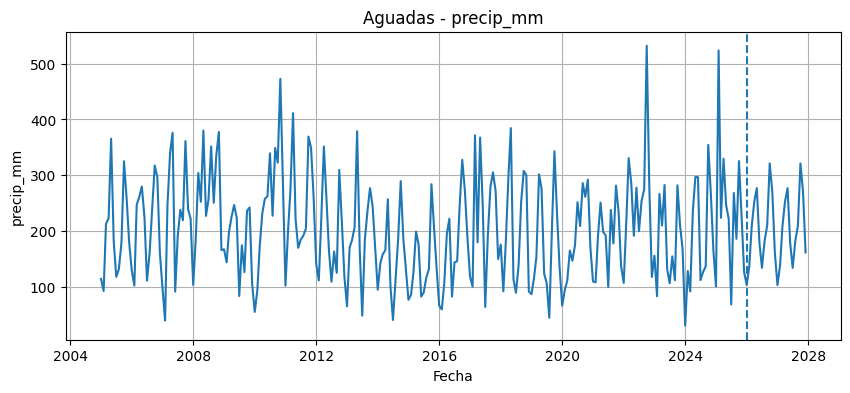

In [17]:

# Cambia estos valores si quieres inspeccionar otra serie
municipio_ejemplo = clima_mes_2005_2027[COL_MUNICIPIO].dropna().unique()[0]
variable_ejemplo = variables_clima[0]

df_plot = clima_mes_2005_2027[
    clima_mes_2005_2027[COL_MUNICIPIO] == municipio_ejemplo
].copy()

plt.figure(figsize=(10, 4))
plt.plot(df_plot["date"], df_plot[variable_ejemplo])
plt.axvline(fecha_inicio, linestyle="--")
plt.title(f"{municipio_ejemplo} - {variable_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel(variable_ejemplo)
plt.grid()
plt.show()


## 11. Guardar archivos

In [18]:

salida_clima_mes = path / "clima_mes_2005-2027.csv"
salida_pronostico = path / "clima_mes_pronostico_2025-2027.csv"
salida_metricas = path / "metricas_pronostico_climatico.csv"
salida_modelos = path / "modelos_seleccionados_pronostico.csv"

clima_mes_2005_2027.to_csv(salida_clima_mes, index=False)
pronosticos_wide.to_csv(salida_pronostico, index=False)
metricas_modelos.to_csv(salida_metricas, index=False)

modelos_seleccionados = (
    metricas_modelos
    .sort_values(["municipio", "variable", "rmse"])
    .groupby(["municipio", "variable"])
    .first()
    .reset_index()
)

modelos_seleccionados.to_csv(salida_modelos, index=False)

print("Archivos guardados:")
print(salida_clima_mes)
print(salida_pronostico)
print(salida_metricas)
print(salida_modelos)


Archivos guardados:
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/clima_mes_2005-2027.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/clima_mes_pronostico_2025-2027.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/metricas_pronostico_climatico.csv
/home/ddayann/proyectos/Coffe/proyecto_aplicado_en_analitica_de_datos/data/processed/modelos_seleccionados_pronostico.csv



## 12. Siguiente paso

Con `clima_mes_2005-2027.csv` se debe ejecutar el mismo pipeline de features intra-anuales para construir:

- `features_intra_anuales_2005-2027.csv`
- `features_intra_anuales_2025-2027.csv`

Estas features son las que alimentan el índice de riesgo y la prima.
